In [ ]:
# we import the pandas library 
import pandas as pd


In [2]:
df_penguins = pd.read_csv('../../W4_Pandas_And_Environmental_Data/Data/palmer_penguin_data.csv',
                          sep = ',',
                          na_values='NA',
                          skiprows= 1,
                          index_col=0   # Use the first column as the index of the DataFrame
                          )
df_penguins

df_penguins.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,year
rowid,,,,,,,,
1,Adelie,Torgersen,39.1,18.7,181.0,3750.0,male,2007
2,Adelie,Torgersen,39.5,17.4,186.0,3800.0,female,2007
3,Adelie,Torgersen,40.3,18.0,195.0,3250.0,female,2007
4,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN,2007
5,Adelie,Torgersen,36.7,19.3,193.0,3450.0,female,2007


In [5]:
df_Adelie = df_penguins.loc[df_penguins.species == 'Adelie']
df_Adelie

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,year
rowid,,,,,,,,
1,Adelie,Torgersen,39.1,18.7,181.0,3750.0,male,2007
2,Adelie,Torgersen,39.5,17.4,186.0,3800.0,female,2007
3,Adelie,Torgersen,40.3,18.0,195.0,3250.0,female,2007
4,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN,2007
5,Adelie,Torgersen,36.7,19.3,193.0,3450.0,female,2007
...,...,...,...,...,...,...,...,...
148,Adelie,Dream,36.6,18.4,184.0,3475.0,female,2009
149,Adelie,Dream,36.0,17.8,195.0,3450.0,female,2009
150,Adelie,Dream,37.8,18.1,193.0,3750.0,male,2009


In [11]:
df_Adelie[['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g']].corr()

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
bill_length_mm,1.000000,0.391492,0.325785,0.548866
bill_depth_mm,0.391492,1.000000,0.307620,0.576138
flipper_length_mm,0.325785,0.307620,1.000000,0.468202
body_mass_g,0.548866,0.576138,0.468202,1.000000


In [10]:
import scipy.stats

df_without_nan = df_Adelie.copy().dropna()
x = df_without_nan['bill_length_mm']
y = df_without_nan['bill_depth_mm']

scipy.stats.pearsonr(x, y)

PearsonRResult(statistic=np.float64(0.38581320049557943), pvalue=np.float64(1.514901409647618e-06))

In [13]:
df_without_nan[['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g']].corr()

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
bill_length_mm,1.000000,0.385813,0.332274,0.544276
bill_depth_mm,0.385813,1.000000,0.310897,0.580156
flipper_length_mm,0.332274,0.310897,1.000000,0.464854
body_mass_g,0.544276,0.580156,0.464854,1.000000


<Axes: xlabel='bill_length_mm', ylabel='bill_depth_mm'>

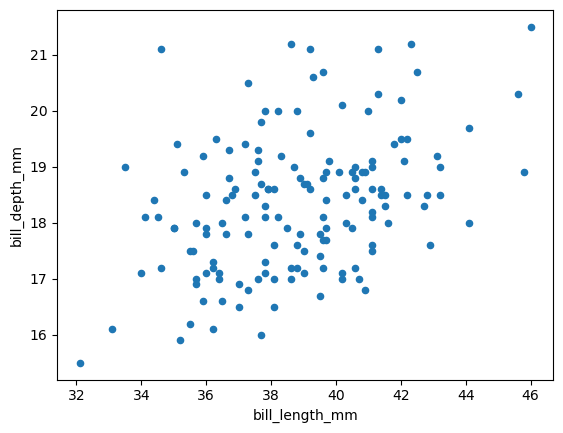

In [15]:
df_Adelie.plot(kind = 'scatter', x='bill_length_mm',y='bill_depth_mm')

In [20]:
res = scipy.stats.linregress(x,y,nan_policy='omit')
print(res)

LinregressResult(slope=np.float64(0.17668344293376206), intercept=np.float64(11.487707126154493), rvalue=np.float64(0.385813200495579), pvalue=np.float64(1.5149014096476628e-06), stderr=np.float64(0.035207899073921585), intercept_stderr=np.float64(1.3700993275268667))


In [21]:
bill_depth_mm_estimated = df_without_nan['bill_length_mm']*res.slope + res.intercept
bill_depth_mm_estimated

rowid
1      18.396030
2      18.466703
3      18.608050
5      17.971989
6      18.431366
         ...    
148    17.954321
149    17.848311
150    18.166341
151    17.848311
152    18.820070
Name: bill_length_mm, Length: 146, dtype: float64

Text(32, 21, 'y = 0.18x + 11.49\n$R^2$ = 0.15')

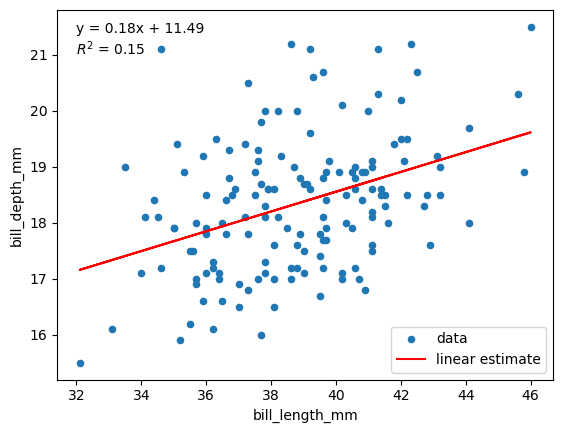

In [36]:
import matplotlib.pyplot as plt
df_Adelie.plot(kind = 'scatter', x='bill_length_mm',y='bill_depth_mm')
plt.plot( df_without_nan['bill_length_mm'], bill_depth_mm_estimated, 'r')
plt.legend(['data', 'linear estimate'])
plt.text(32,21, f'y = {res.slope:.2f}x + {res.intercept:.2f}\n$R^2$ = {(res.rvalue)**2:.2f}')

In [ ]:
residuals = bill_depth_mm_estimated - df_without_nan['bill_depth_mm'] 


PearsonRResult(statistic=np.float64(-7.494005416219807e-16), pvalue=np.float64(0.9999999999999956))


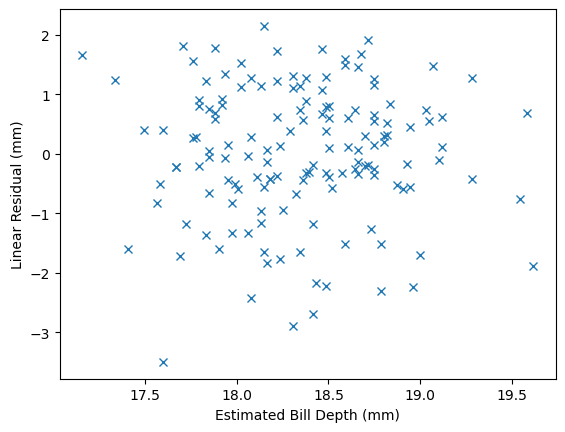

In [ ]:
#residuals
plt.plot(bill_depth_mm_estimated, residuals,  'x')
plt.ylabel('Linear Residual (mm)')
plt.xlabel('Estimated Bill Depth (mm)')


print(scipy.stats.pearsonr(residuals,bill_depth_mm_estimated))

(array([ 1.,  3.,  6., 13.,  8., 35., 25., 25., 21.,  9.]),
 array([-3.49904575, -2.93427388, -2.36950201, -1.80473015, -1.23995828,
        -0.67518641, -0.11041454,  0.45435732,  1.01912919,  1.58390106,
         2.14867292]),
 <BarContainer object of 10 artists>)

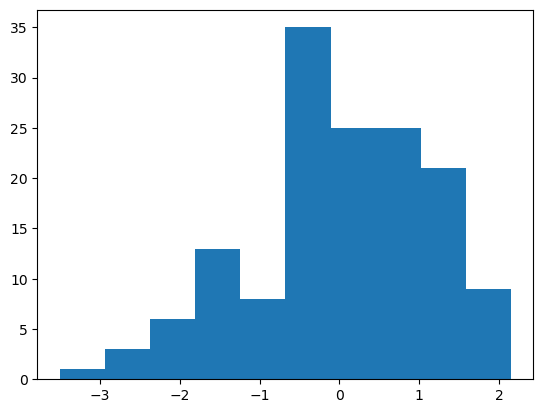

In [72]:
plt.hist(residuals)

In [60]:
import statsmodels.formula.api as smf 
import statsmodels.api as sm 

df_Adelie = df_Adelie.dropna()

y = df_Adelie['body_mass_g']
X = df_Adelie[['bill_length_mm','bill_depth_mm','flipper_length_mm']]
X = sm.add_constant(X) 
est = sm.OLS(y, X).fit() 
est.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:            body_mass_g   R-squared:                       0.506
Model:                            OLS   Adj. R-squared:                  0.496
Method:                 Least Squares   F-statistic:                     48.57
Date:                Mon, 13 Apr 2026   Prob (F-statistic):           1.16e-21
Time:                        12:38:19   Log-Likelihood:                -1049.8
No. Observations:                 146   AIC:                             2108.
Df Residuals:                     142   BIC:                             2120.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
=====================================================================================
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
const             -4270.6550    811.928     -5.260      0.000   -5875.683   -2665.627
bill_length_mm       54.5124     11.345      4.805      0.000      32.086      76.939
bill_depth_mm       144.1567     24.584      5.864      0.000      95.559     192.754
flipper_length_mm    16.9148      4.496      3.762      0.000       8.027      25.802
==============================================================================
Omnibus:                        2.005   Durbin-Watson:                   2.047
Prob(Omnibus):                  0.367   Jarque-Bera (JB):                1.735
Skew:                           0.265   Prob(JB):                        0.420
Kurtosis:                       3.062   Cond. No.                     5.88e+03
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 5.88e+03. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [65]:
df_Adelie['flipper_length_squared'] = df_Adelie['flipper_length_mm']**2
est = smf.ols(formula='body_mass_g ~ bill_length_mm + bill_depth_mm + flipper_length_squared', data=df_Adelie).fit()
est.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:            body_mass_g   R-squared:                       0.507
Model:                            OLS   Adj. R-squared:                  0.496
Method:                 Least Squares   F-statistic:                     48.59
Date:                Mon, 13 Apr 2026   Prob (F-statistic):           1.14e-21
Time:                        12:42:06   Log-Likelihood:                -1049.8
No. Observations:                 146   AIC:                             2108.
Df Residuals:                     142   BIC:                             2120.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
==========================================================================================
                             coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------
Intercept              -2660.5420    531.996     -5.001      0.000   -3712.198   -1608.886
bill_length_mm            54.3042     11.356      4.782      0.000      31.855      76.754
bill_depth_mm            144.3446     24.570      5.875      0.000      95.775     192.914
flipper_length_squared     0.0445      0.012      3.767      0.000       0.021       0.068
==============================================================================
Omnibus:                        2.055   Durbin-Watson:                   2.047
Prob(Omnibus):                  0.358   Jarque-Bera (JB):                1.785
Skew:                           0.269   Prob(JB):                        0.410
Kurtosis:                       3.061   Cond. No.                     7.16e+05
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 7.16e+05. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [67]:
df_Adelie['sex_ord'] = pd.Categorical(df_Adelie['sex']).labels 
df_Adelie

AttributeError: 'Categorical' object has no attribute 'labels'

In [71]:
est = smf.ols(formula='body_mass_g ~ bill_length_mm + bill_depth_mm + sex_ord', data=df_Adelie).fit()
est.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:            body_mass_g   R-squared:                       0.591
Model:                            OLS   Adj. R-squared:                  0.582
Method:                 Least Squares   F-statistic:                     68.34
Date:                Mon, 13 Apr 2026   Prob (F-statistic):           2.07e-27
Time:                        12:45:27   Log-Likelihood:                -1036.2
No. Observations:                 146   AIC:                             2080.
Df Residuals:                     142   BIC:                             2092.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
===================================================================================
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
Intercept         984.4166    601.200      1.637      0.104    -204.042    2172.875
sex_ord[T.male]   476.6000     69.999      6.809      0.000     338.224     614.976
bill_length_mm     26.8589     11.471      2.342      0.021       4.184      49.534
bill_depth_mm      78.5228     25.199      3.116      0.002      28.709     128.337
==============================================================================
Omnibus:                        0.550   Durbin-Watson:                   1.928
Prob(Omnibus):                  0.760   Jarque-Bera (JB):                0.693
Skew:                           0.093   Prob(JB):                        0.707
Kurtosis:                       2.718   Cond. No.                     1.06e+03
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 1.06e+03. This might indicate that there are
strong multicollinearity or other numerical problems.
"""